<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 32 · Part VI Probability</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Counting &amp; Combinatorics 🔢</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:720px;line-height:1.6">Before you can compute a probability, you often have to count: how many outcomes are there? The multiplication principle, permutations, and combinations are the tools that count without listing.</div>
  <div style="margin-top:16px;font-size:13px;color:#cbd5e1">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, matplotlib.pyplot as plt, math, itertools
from math import factorial, perm, comb
BLUE="#2563eb"; INDIGO="#4f46e5"; GREEN="#059669"; AMBER="#d97706"; PURPLE="#7c3aed"; PINK="#db2777"; INK="#1a2138"; GRID="#e6e9f2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
print("ready")

ready


<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#4f46e5;letter-spacing:1px">DEMO 1 · MULTIPLICATION PRINCIPLE</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">Count without listing</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">If a task is a sequence of independent choices with n1, n2, n3, ... options, the total number of outcomes is the <b>product</b> n1 x n2 x n3 ... The fundamental counting principle.</div>
</div>

In [2]:
shirts, pants, shoes = 3, 4, 2
total = shirts * pants * shoes
print(f"outfits = {shirts} x {pants} x {shoes} = {total}")
# verify by actually listing every combination
combos = list(itertools.product(range(shirts), range(pants), range(shoes)))
print(f"enumerated outfits: {len(combos)}  (matches the product)")

# a 4-digit PIN: 10 choices per position, repetition allowed
print(f"\n4-digit PINs = 10^4 = {10**4:,}")
# a license plate: 3 letters then 3 digits
print(f"plates (3 letters + 3 digits) = 26^3 x 10^3 = {26**3 * 10**3:,}")

outfits = 3 x 4 x 2 = 24
enumerated outfits: 24  (matches the product)

4-digit PINs = 10^4 = 10,000
plates (3 letters + 3 digits) = 26^3 x 10^3 = 17,576,000


**Multiply the choices.** Each independent decision multiplies the number of possibilities. Three shirts, four pants, and two pairs of shoes give 3 x 4 x 2 = 24 outfits, and you never had to write them all out. When repetition is allowed (PIN digits, plate characters), each slot simply contributes its full count again.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#2563eb;letter-spacing:1px">DEMO 2 · PERMUTATIONS</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">When order matters</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">A <b>permutation</b> is an ordered arrangement. Arranging all n distinct items gives n! orderings; choosing and ordering r of them gives nPr = n! / (n-r)!.</div>
</div>

In [3]:
print("factorials:", {n: factorial(n) for n in range(0,7)})

# how many ways to award gold, silver, bronze among 8 runners? order matters
n, r = 8, 3
print(f"\nP({n},{r}) = {n}! / ({n}-{r})! = {perm(n,r)}")
# verify by enumeration
print("enumerated ordered podiums:", len(list(itertools.permutations(range(n), r))))

# arranging all 5 distinct books on a shelf
print(f"\narrange 5 books = 5! = {factorial(5)}")

factorials: {0: 1, 1: 1, 2: 2, 3: 6, 4: 24, 5: 120, 6: 720}

P(8,3) = 8! / (8-3)! = 336
enumerated ordered podiums: 336

arrange 5 books = 5! = 120


**Order matters, so count the orderings.** With 8 runners, the number of distinct gold-silver-bronze finishes is P(8,3) = 8 x 7 x 6 = 336, because the first medal has 8 candidates, the second 7, the third 6. Arranging all of something is the special case nPn = n!. Note 0! = 1 by convention, which keeps the formulas consistent.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#059669;letter-spacing:1px">DEMO 3 · COMBINATIONS</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">When order does NOT matter</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">A <b>combination</b> is an unordered selection. Choosing r from n is nCr = n! / (r! (n-r)!), read "n choose r". Because order is ignored, every group is counted once.</div>
</div>

In [4]:
n, r = 8, 3
print(f"C({n},{r}) = {comb(n,r)}     P({n},{r}) = {perm(n,r)}")
print(f"relationship: C(n,r) = P(n,r) / r!  ->  {perm(n,r)} / {factorial(r)} = {perm(n,r)//factorial(r)}")
print("enumerated unordered groups:", len(list(itertools.combinations(range(n), r))))

# compare ordered vs unordered for choosing 2 of {A,B,C}
items = ["A","B","C"]
print("\npermutations of 2:", ["".join(p) for p in itertools.permutations(items,2)])
print("combinations of 2:", ["".join(c) for c in itertools.combinations(items,2)])

C(8,3) = 56     P(8,3) = 336
relationship: C(n,r) = P(n,r) / r!  ->  336 / 6 = 56
enumerated unordered groups: 56

permutations of 2: ['AB', 'AC', 'BA', 'BC', 'CA', 'CB']
combinations of 2: ['AB', 'AC', 'BC']


**Drop the order, divide by r!.** Every unordered group of r items can be ordered in r! ways, so combinations are just permutations with that overcount removed: C(n,r) = P(n,r) / r!. Choosing 2 of {A, B, C} gives 6 ordered pairs (AB, BA, AC, CA, BC, CB) but only 3 actual pairs (AB, AC, BC). "Order matters" is the single question that decides permutation vs combination.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#db2777;letter-spacing:1px">DEMO 4 · COUNTING FOR PROBABILITY</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">Favorable over total</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">Classical probability is favorable outcomes / total outcomes, and combinatorics counts both. Two classics: lottery odds and a poker hand.</div>
</div>

In [5]:
# Lottery: choose 6 numbers from 49, order does not matter -> combinations
total = comb(49,6)
print(f"6/49 lottery: total tickets = C(49,6) = {total:,}")
print(f"P(jackpot with one ticket) = 1/{total:,} = {1/total:.2e}")

# Poker: P(all 5 cards the same suit, a flush) from a 52-card deck
hands = comb(52,5)
flush = 4 * comb(13,5)          # 4 suits, choose 5 of the 13 cards in a suit
print(f"\npoker: total 5-card hands = C(52,5) = {hands:,}")
print(f"flush hands = 4 x C(13,5) = {flush:,}")
print(f"P(flush) = {flush}/{hands} = {flush/hands:.5f}  (about 1 in {round(hands/flush)})")

6/49 lottery: total tickets = C(49,6) = 13,983,816
P(jackpot with one ticket) = 1/13,983,816 = 7.15e-08

poker: total 5-card hands = C(52,5) = 2,598,960
flush hands = 4 x C(13,5) = 5,148
P(flush) = 5148/2598960 = 0.00198  (about 1 in 505)


**Counting is the hard part of classical probability.** Picking 6 lottery numbers is an unordered choice, so there are C(49,6) = 13,983,816 possible tickets and a single ticket wins the jackpot with probability about 1 in 14 million. For a flush, count the favorable hands (pick a suit, then 5 of its 13 cards) over all C(52,5) hands. Once you can count, the probability is just a ratio.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#d97706;letter-spacing:1px">DEMO 5 · PASCAL'S TRIANGLE</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">Where the combinations live</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">Every entry of Pascal's triangle is a combination C(n,r), and row n holds the coefficients of (a+b)^n. It connects counting to the binomial distribution coming next.</div>
</div>

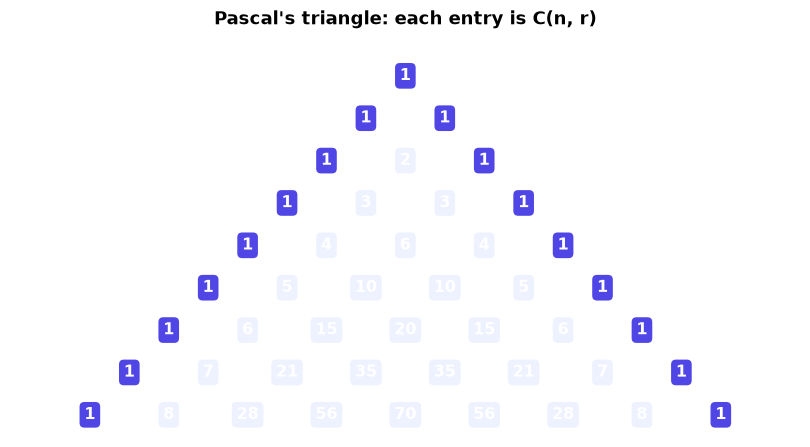

row 4 = [1, 4, 6, 4, 1] = the coefficients of (a+b)^4: a^4 + 4a^3b + 6a^2b^2 + 4ab^3 + b^4
each entry is the sum of the two above it (e.g. 6 = 3 + 3)


In [6]:
rows = 9
tri = [[comb(n,r) for r in range(n+1)] for n in range(rows)]
fig, ax = plt.subplots(figsize=(7.5,4.2))
for n in range(rows):
    for r in range(n+1):
        x = r - n/2
        col = PINK if (r in (0,n)) else INK
        ax.text(x, -n, str(tri[n][r]), ha="center", va="center", fontsize=10.5,
                color="white", fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", fc=INDIGO if r in (0,n) else "#eef2ff", ec="none"))
ax.set_xlim(-rows/2-0.5, rows/2+0.5); ax.set_ylim(-rows+0.5, 1)
ax.axis("off"); ax.set_title("Pascal's triangle: each entry is C(n, r)")
plt.tight_layout(); plt.show()

print("row 4 =", tri[4], "= the coefficients of (a+b)^4: a^4 + 4a^3b + 6a^2b^2 + 4ab^3 + b^4")
print("each entry is the sum of the two above it (e.g. 6 = 3 + 3)")

**Counting, drawn.** Pascal's triangle, documented by Pascal in 1653 but known to Pingala, al-Karaji, Khayyam, and Yang Hui centuries earlier, simply tabulates C(n, r). Row n is the binomial expansion of (a+b)^n, which is exactly why the number of ways to get r successes in n trials, C(n, r), drives the binomial distribution in the next chapters.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">🎯 Recap</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:8px">
<li><b>Multiplication principle:</b> a sequence of choices multiplies, n1 x n2 x n3 ...</li>
<li><b>Permutation (order matters):</b> P(n,r) = n! / (n-r)!; arrange all n in n! ways.</li>
<li><b>Combination (order ignored):</b> C(n,r) = n! / (r!(n-r)!) = P(n,r) / r!.</li>
<li><b>Counting for probability:</b> classical probability = favorable / total, both counted with these tools; Pascal's triangle holds every C(n,r).</li>
</ul>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>